In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from photerr import LsstErrorModel
import os.path

In [2]:
import photerr
print(photerr.__version__)

1.1.1


Note: need to upgrade photerr to v1.2.1

In [3]:
# load pickle:
import pickle

def dump_load(filename):
    with open(filename,'rb') as fin:
        stuff=pickle.load(fin)
        #self.impute = json.load(fin)
    #print('loaded impute ditionary:',filename)
    return stuff

def dump_save(stuff,filename):
    '''This saves the dictionary and loads it from appropriate files'''
    with open(filename,'wb') as fout:
        pickle.dump(stuff,fout,pickle.HIGHEST_PROTOCOL)
        #json.dump(self.impute, fout, sort_keys=True, indent=3)
    #print('written impute ditionary:',filename)
    return 0

In [4]:
savedir="/pscratch/sd/q/qhang/roman-rubin-sims/nonuniform-maf/"

In [5]:
# load the dataset:

fname=savedir+"roman_rubin_2023_v1.1.3_elais-subset.pkl"
sample = dump_load(fname)
print(sample[:5])

           u          g          r          i          z          y  redshift  \
0  26.540577  26.384027  25.733800  25.504399  25.519280  25.339558  0.496281   
1  23.655804  23.172198  22.195872  21.390342  21.108981  20.965564  0.664130   
2  27.682149  26.924397  26.687338  26.464906  26.316293  26.091850  2.352268   
3  26.371711  26.360558  26.417829  26.357415  26.258483  25.838584  1.525202   
4  25.146077  24.793759  24.422706  23.885986  23.252067  22.768708  1.264607   

      major     minor  
0  0.096534  0.048828  
1  0.485163  0.255614  
2  0.356234  0.239662  
3  0.092762  0.039709  
4  0.297771  0.196978  


In [6]:
nominal_depth_LSSTY10 = {
    "u":25.6,
    "g":26.9,
    "r":26.9,
    "i":26.4,
    "z":25.6,
    "y":24.8,
}

In [7]:
# set up grid of 5 sigma depths to consider

# number of bins to perturb
n_m5 = 11
dm5 = 0.1
# this evolves with the nominal depth in each year, bin width = 0.1

# choose nominal years to output Fixed to Y1 for now
years=np.arange(1,11)
n_ilim=len(years)
ilims = 25.3+2.5/2.0*np.log10(years/10)
print("i_lim", ilims)

nominal_depth={}
for band in ["u","g","r","i","z","y"]:
    nominal_depth[band] = {}
    for year in years:
        #nominal_depth[band][year]= nominal_depth_LSSTv1[band]+2.5/2.0*np.log10(year)
        nominal_depth[band][year]= nominal_depth_LSSTY10[band]+2.5/2.0*np.log10(year/10)
    print(band, nominal_depth[band])
    
# finally compute the M5 bins in each band:
M5 = {}
for band in ["u","g","r","i","z","y"]:
    M5[band]={}
    for year in years:
        M5[band][year] = np.linspace(-5,5,n_m5)*0.1 +  nominal_depth[band][year]
print(M5["i"])

i_lim [24.05       24.42628749 24.64640157 24.80257499 24.92371251 25.02268906
 25.10637255 25.17886248 25.24280314 25.3       ]
u {1: 24.35, 2: 24.726287494579978, 3: 24.94640156839958, 4: 25.102574989159955, 5: 25.223712505420025, 6: 25.322689062979556, 7: 25.40637255001782, 8: 25.47886248373993, 9: 25.542803136799158, 10: 25.6}
g {1: 25.65, 2: 26.026287494579975, 3: 26.246401568399577, 4: 26.40257498915995, 5: 26.523712505420022, 6: 26.622689062979553, 7: 26.706372550017818, 8: 26.77886248373993, 9: 26.842803136799155, 10: 26.9}
r {1: 25.65, 2: 26.026287494579975, 3: 26.246401568399577, 4: 26.40257498915995, 5: 26.523712505420022, 6: 26.622689062979553, 7: 26.706372550017818, 8: 26.77886248373993, 9: 26.842803136799155, 10: 26.9}
i {1: 25.15, 2: 25.526287494579975, 3: 25.746401568399577, 4: 25.90257498915995, 5: 26.023712505420022, 6: 26.122689062979553, 7: 26.206372550017818, 8: 26.27886248373993, 9: 26.342803136799155, 10: 26.4}
z {1: 24.35, 2: 24.726287494579978, 3: 24.9464015683

In [8]:
print(savedir)

/pscratch/sd/q/qhang/roman-rubin-sims/nonuniform-maf/


In [17]:
# what we want to do here is to degrade the sample and save them in a separate catalogue;
# let's say save them as pickle

extendedType="auto"
catalog_rep = sample.copy()

# we should save the binning in each band:

for idx_lim,ilim in enumerate([ilims[0]]):
    # make a directory:
    savedir2= savedir+f"Y{years[idx_lim]}/"
    if os.path.exists(savedir2)==False:
        os.mkdir(savedir2)
        
    print(f"Working on Y{years[idx_lim]}...")

    for band in ["u","g","r","i","z","y"]:
        m5s=M5[band][years[idx_lim]]
        
        # these are nominal values
        nVisYr={}
        m5={}
        for bb in ["u","g","r","i","z","y"]:
            nVisYr[bb]=1
            m5[bb]=nominal_depth[bb][years[idx_lim]]
        
        for idx,m5_spec in enumerate(m5s):
            # make a file name
            fname=savedir2+f"roman-rubin_sample-m5-{band}-bin-{idx+1}.pkl"
            # we need nominal values + the band that gets perturbed
            # set up error model with defualt params
            # overwrite m5 with the ones we want
            m5[band] = m5_spec
            errModel = LsstErrorModel(nYrObs=1,nVisYr=nVisYr,m5={"u": float(m5["u"]),
                                                                "g": float(m5["g"]),
                                                                "r": float(m5["r"]),
                                                                "i": float(m5["i"]),
                                                                 "z": float(m5["z"]),
                                                                "y": float(m5["y"])},
                                     extendedType=extendedType)
            tmpcatalog = errModel(catalog_rep, random_state=np.random.randint(1,100_000))
            # save tmpcatalog:
            # output should be: u,g,r,i,z,y + cuts in ilim:
            d = {
                "u": (tmpcatalog["u"].to_numpy()),
                "g": (tmpcatalog["g"].to_numpy()),
                "r": (tmpcatalog["r"].to_numpy()),
                "i": (tmpcatalog["i"].to_numpy()),
                "z": (tmpcatalog["z"].to_numpy()),
                "y": (tmpcatalog["y"].to_numpy()),
                "u_err": (tmpcatalog["u_err"].to_numpy()),
                "g_err": (tmpcatalog["g_err"].to_numpy()),
                "r_err": (tmpcatalog["r_err"].to_numpy()),
                "i_err": (tmpcatalog["i_err"].to_numpy()),
                "z_err": (tmpcatalog["z_err"].to_numpy()),
                "y_err": (tmpcatalog["y_err"].to_numpy()),
            }
            outputs = pd.DataFrame(data=d)
            dump_save(outputs, fname)

Working on Y1...


In [10]:
# save the bins:
# finally compute the M5 bins in each band:
for year in years:
    savedir2= savedir+f"Y{year}/"
    for band in ["u","g","r","i","z","y"]:
        fname=savedir2+f"m5-{band}-bins.txt"
        np.savetxt(fname, M5[band][year])

Co-varying all bands!

In [18]:
# what we want to do here is to degrade the sample and save them in a separate catalogue;
# let's say save them as pickle

#extendedType="point"
extendedType="auto"

catalog_rep = sample.copy()

for idx_lim,ilim in enumerate([ilims[0]]):
    # make a directory:
    savedir2= savedir+f"Y{years[idx_lim]}/"
    if os.path.exists(savedir2)==False:
        os.mkdir(savedir2)
    
    print(f"Working on Y{years[idx_lim]}...")
        
    # these are nominal values
    nVisYr={}
    #m5={}
    for bb in ["u","g","r","i","z","y"]:
        nVisYr[bb]=1
        #m5[bb]=nominal_depth[bb][years[idx_lim]]

    for idx in range(n_m5):
        # make a file name
        fname=savedir2+f"roman-rubin_sample-m5-ugrizy-bin-{idx+1}.pkl"
        # we need nominal values + the band that gets perturbed
        # set up error model with defualt params
        # overwrite m5 with the ones we want
        errModel = LsstErrorModel(nYrObs=1,nVisYr=nVisYr,m5={"u": float(M5["u"][years[idx_lim]][idx]),
                                                             "g": float(M5["g"][years[idx_lim]][idx]),
                                                             "r": float(M5["r"][years[idx_lim]][idx]),
                                                             "i": float(M5["i"][years[idx_lim]][idx]),
                                                             "z": float(M5["z"][years[idx_lim]][idx]),
                                                             "y": float(M5["y"][years[idx_lim]][idx])},
                                 extendedType=extendedType)
        tmpcatalog = errModel(catalog_rep, random_state=np.random.randint(1,100_000))

        # save tmpcatalog:
        # output should be: u,g,r,i,z,y
        d = {
            "u": (tmpcatalog["u"].to_numpy()),
            "g": (tmpcatalog["g"].to_numpy()),
            "r": (tmpcatalog["r"].to_numpy()),
            "i": (tmpcatalog["i"].to_numpy()),
            "z": (tmpcatalog["z"].to_numpy()),
            "y": (tmpcatalog["y"].to_numpy()),
            "u_err": (tmpcatalog["u_err"].to_numpy()),
            "g_err": (tmpcatalog["g_err"].to_numpy()),
            "r_err": (tmpcatalog["r_err"].to_numpy()),
            "i_err": (tmpcatalog["i_err"].to_numpy()),
            "z_err": (tmpcatalog["z_err"].to_numpy()),
            "y_err": (tmpcatalog["y_err"].to_numpy()),
        }
        outputs = pd.DataFrame(data=d)
        dump_save(outputs, fname)

Working on Y1...


Sanity checks

In [12]:
yr=1
band="z"
m5s=M5[band][yr]
ilim=ilims[0]
idx=5
savedir2 = savedir+f"Y{yr}/"
fname=savedir2+f"roman-rubin_sample-m5-{band}-bin-{idx+1}.pkl"
catalog = dump_load(fname)

In [13]:
catalog[:5]

,u,g,r,i,z,y,u_err,g_err,r_err,i_err,z_err,y_err
0,25.064732,26.806498,25.173066,25.594142,27.143669,27.512714,0.391754,0.552156,0.153199,0.327830,1.523784,2.504263
1,23.332099,23.229739,22.150798,21.401156,21.164439,20.900205,0.221364,0.072283,0.033177,0.028524,0.043766,0.066893
2,inf,27.121911,26.961215,25.343712,24.552807,24.584741,inf,1.152907,1.081042,0.529428,0.543228,0.953530
3,25.852228,26.646451,25.851892,26.156797,27.226710,24.811896,0.683672,0.484582,0.264020,0.495422,1.569707,0.600285
4,25.566801,25.132243,24.518433,23.823492,23.587434,22.661922,0.870965,0.255454,0.160651,0.139535,0.226449,0.206670


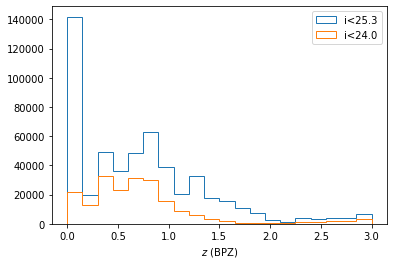

In [15]:
# check bpz results:
yr=1
band="z"
m5s=M5[band][yr]
ilim=ilims[0]
idx=0
savedir2 = savedir+f"Y{yr}/bpz/"
fname = savedir2 + f"zmode-odds-m5-{band}-bin-6.pkl"
fin = dump_load(fname)

ind=catalog["i"]<25.3
cc=plt.hist(fin[ind,0], bins=20, histtype='step',label= "i<25.3")
plt.xlabel("$z$ (BPZ)")

ind=catalog["i"]<24.0
cc=plt.hist(fin[ind,0], bins=20, histtype='step',label= "i<24.0")
plt.xlabel("$z$ (BPZ)")
plt.legend()

Text(0.5, 1.0, 'i<24')

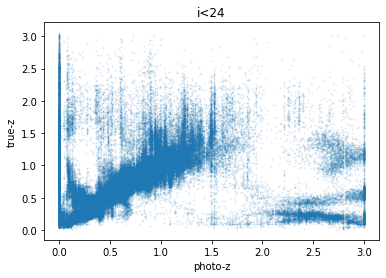

In [16]:
# scatter plot:
ind=catalog["i"]<24.0
plt.scatter(fin[ind,0], sample["redshift"][ind], s=1, alpha=0.1)
plt.xlabel("photo-z")
plt.ylabel("true-z")
plt.title("i<24")

In [17]:
def plot_and_stats(zspec,zphot):
    
    z_spec = np.copy(zspec)
    z_phot=np.copy(zphot)
    x = np.arange(0,5.4,0.05)

# define differences of >0.15*(1+z) as non-Gaussian 'outliers'    
    outlier_upper = x + 0.15*(1+x)
    outlier_lower = x - 0.15*(1+x)

    mask = np.abs((z_phot - z_spec)/(1 + z_spec)) > 0.15
    notmask = ~mask 
    
#Standard Deviation of the predicted redshifts compared to the data:
    std_result = np.std((z_phot - z_spec)/(1 + z_spec), ddof=1)

#Normalized MAD (Median Absolute Deviation):
    nmad = 1.48 * np.median(np.abs((z_phot - z_spec)/(1 + z_spec)))

#Percentage of delta-z > 0.15(1+z) outliers:
    eta = np.sum(np.abs((z_phot - z_spec)/(1 + z_spec)) > 0.15)/len(z_spec)
    
    #Median offset (normalized by (1+z); i.e., bias:
    bias = np.median(((z_phot - z_spec)/(1 + z_spec)))
    sigbias=std_result/np.sqrt(0.64*len(z_phot))
    
    # make photo-z/spec-z plot
    plt.figure(figsize=(8, 8))
    
    #add lines to indicate outliers
    plt.plot(x, outlier_upper, 'k--')
    plt.plot(x, outlier_lower, 'k--')
    plt.plot(z_spec[mask], z_phot[mask], 'r.', markersize=6,  alpha=0.05)
    plt.plot(z_spec[notmask], z_phot[notmask], 'b.',  markersize=6, alpha=0.05)
    plt.plot(x, x, linewidth=1.5, color = 'red')
    plt.title('$\sigma_\mathrm{NMAD} \ = $%6.4f\n'%nmad+'$(\Delta z)>0.15(1+z) $ outliers = %6.3f'%(eta*100)+'%', fontsize=18)
    plt.xlim([0.0, 2])
    plt.ylim([0.0, 2])
    plt.xlabel('$z_{\mathrm{spec}}$', fontsize = 27)
    plt.ylabel('$z_{\mathrm{photo}}$', fontsize = 27)
    plt.grid(alpha = 0.8)
    plt.tick_params(labelsize=15)
    plt.show()
    
    


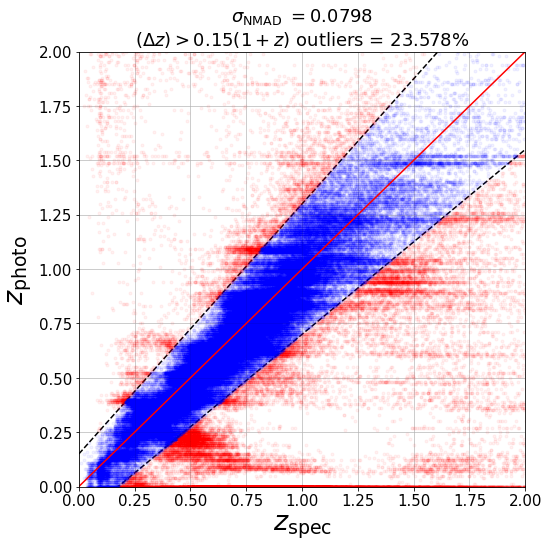

In [18]:
plot_and_stats(sample["redshift"][ind],fin[ind,0])

In [13]:
# load i-band variation and check results:
yr=1
band="i"
m5s=M5[band][yr]
ilim=ilims[0]

true_z = catalog_rep['redshift']
true_i = catalog_rep['i']

meanz = np.zeros(n_m5)
meanz_error = np.zeros_like(meanz)

number = np.zeros_like(meanz)
number_error = np.zeros_like(meanz)

meanz_true = np.mean(catalog_rep[true_i < ilim]['redshift'])
number_true = np.sum(true_i < ilim)

savedir2 = savedir+f"Y{yr}/"

for idx,m5_spec in enumerate(m5s):
    # make a file name
    fname=savedir2+f"roman-rubin_sample-m5-{band}-bin-{idx+1}.pkl"
    catalog = dump_load(fname)
    
    noisy_i = catalog["i"]
    meanz[idx] = np.mean(sample[noisy_i < ilim]['redshift'])
    number[idx] = np.sum(noisy_i < ilim)
    meanz_error[idx] = np.std(tmpcatalog[noisy_i < ilim]['redshift']) / np.sqrt(number[idx])
    number_error[idx] = np.sqrt(number[idx])
d= {'year':1,'ilimit':ilim,'true_meanz':meanz_true,'true_n':number_true,'m5':m5s,'meanz':meanz,
         'number': number, 'meanz_err':meanz_error,'number_err':number_error }
outputs =pd.DataFrame(data=d)

Text(0.5, 1.0, "extendedType='auto', nominal noise on all other bands")

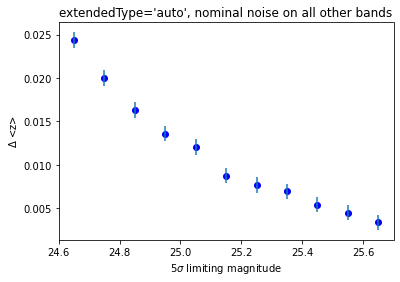

In [14]:
plt.plot(outputs['m5'],outputs['meanz']-outputs['true_meanz'],'bo')
plt.errorbar(outputs['m5'],outputs['meanz']-outputs['true_meanz'],outputs['meanz_err'],
            fmt='none')
plt.xlabel(r'5$\sigma$ limiting magnitude')
plt.ylabel(r'$\Delta$ <z>')
plt.title("extendedType='auto', nominal noise on all other bands")

In [17]:
savedir2=savedir+"Y1/"
fname=savedir2+f"roman-rubin_sample-m5-{band}-bin-{6}.pkl"
print(fname)
catalog = dump_load(fname)

/pscratch/sd/q/qhang/roman-rubin-sims/nonuniform-maf/Y1/roman-rubin_sample-m5-i-bin-6.pkl


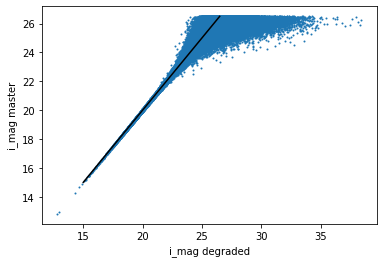

In [20]:
plt.scatter(catalog['i'],sample['i'],s=1)
plt.xlabel("i_mag degraded")
plt.ylabel("i_mag master")
plt.plot([15,26.5],[15,26.5],'k-')

## Test i-band Y1 for the other size set up?

In [6]:
# convert:
a=sample["major"]
b=sample["minor"]
size=np.sqrt(a*b)
q=b/a
size_minor = size*q

sample2=sample.drop(['major', 'minor'], axis=1)
# now append the new major, minor
df2=pd.DataFrame(size, columns=['major'],index=np.arange(len(size)))
df3=pd.DataFrame(size_minor, columns=['minor'],index=np.arange(len(size)))
df=pd.concat([df2, df3], names=['major','minor'], axis=1)
sample2 = pd.concat([sample2,df], axis=1)

In [8]:
sample2[:5]

,u,g,r,i,z,y,redshift,major,minor
0,26.540577,26.384027,25.733800,25.504399,25.519280,25.339558,0.496281,0.068656,0.034727
1,23.655804,23.172198,22.195872,21.390342,21.108981,20.965564,0.664130,0.352157,0.185538
2,27.682149,26.924397,26.687338,26.464906,26.316293,26.091850,2.352268,0.292192,0.196577
3,26.371711,26.360558,26.417829,26.357415,26.258483,25.838584,1.525202,0.060692,0.025981
4,25.146077,24.793759,24.422706,23.885986,23.252067,22.768708,1.264607,0.242186,0.160208


In [9]:
sample[:5]

,u,g,r,i,z,y,redshift,major,minor
0,26.540577,26.384027,25.733800,25.504399,25.519280,25.339558,0.496281,0.096534,0.048828
1,23.655804,23.172198,22.195872,21.390342,21.108981,20.965564,0.664130,0.485163,0.255614
2,27.682149,26.924397,26.687338,26.464906,26.316293,26.091850,2.352268,0.356234,0.239662
3,26.371711,26.360558,26.417829,26.357415,26.258483,25.838584,1.525202,0.092762,0.039709
4,25.146077,24.793759,24.422706,23.885986,23.252067,22.768708,1.264607,0.297771,0.196978


In [14]:
# now measure meanz vs i-band for Y1:
extendedType="auto"

catalog_rep = sample2.copy()

true_z = catalog_rep['redshift']
true_i = catalog_rep['i']

meanz = np.zeros(n_m5)
meanz_error = np.zeros_like(meanz)

number = np.zeros_like(meanz)
number_error = np.zeros_like(meanz)

# we should save the binning in each band:

for idx_lim,ilim in enumerate([ilims[0]]):
    
    meanz_true = np.mean(catalog_rep[true_i < ilim]['redshift'])
    number_true = np.sum(true_i < ilim)
    
    for band in ["i"]:
        m5s=M5[band][years[idx_lim]]
        
        # these are nominal values
        nVisYr={}
        m5={}
        for bb in ["u","g","r","i","z","y"]:
            nVisYr[bb]=1
            m5[bb]=nominal_depth[bb][years[idx_lim]]
        
        for idx,m5_spec in enumerate(m5s):
            # make a file name
            # we need nominal values + the band that gets perturbed
            # set up error model with defualt params
            # overwrite m5 with the ones we want
            m5[band] = m5_spec
            errModel = LsstErrorModel(nYrObs=1,nVisYr=nVisYr,m5={"u": float(m5["u"]),
                                                                "g": float(m5["g"]),
                                                                "r": float(m5["r"]),
                                                                "i": float(m5["i"]),
                                                                 "z": float(m5["z"]),
                                                                "y": float(m5["y"])},
                                     extendedType=extendedType)
            tmpcatalog = errModel(catalog_rep, random_state=np.random.randint(1,100_000))
            #fluxes = 10**(-0.4*(tmpcatalog['i'] - 27))
            #fluxerrs = tmpcatalog['i_err']*np.log(10)/2.5*fluxes
            #noisy_i_flux = fluxes + fluxerrs*np.random.normal(size=tmpcatalog.count()[0])
            # don't let fluxes go negative: limit corresponds to magnitude = 32
            #noisy_i_flux = np.maximum(noisy_i_flux, 0.01)
            #noisy_i = 27 - 2.5*np.log10(noisy_i_flux)
            # populate arrays    
            noisy_i = tmpcatalog["i"]
            meanz[idx] = np.mean(tmpcatalog[noisy_i < ilim]['redshift'])
            number[idx] = sum(noisy_i < ilim)
            meanz_error[idx] = np.std(tmpcatalog[noisy_i < ilim]['redshift']) / np.sqrt(number[idx])
            number_error[idx] = np.sqrt(number[idx])

            # set up and write dataframe
            d= {'year':years[idx_lim],'ilimit':ilim,'true_meanz':meanz_true,'true_n':number_true,'m5':m5s,'meanz':meanz,
         'number': number, 'meanz_err':meanz_error,'number_err':number_error }
            outputs = pd.DataFrame(data=d)
            #outputs.to_feather(summary_filename)

Text(0.5, 1.0, "extendedType='auto', nominal noise on all other bands")

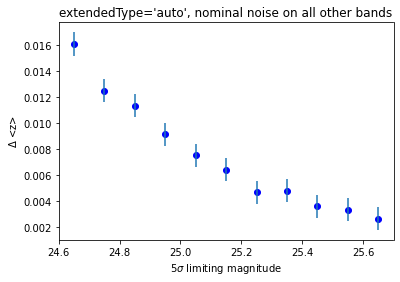

In [15]:
plt.plot(outputs['m5'],outputs['meanz']-outputs['true_meanz'],'bo')
plt.errorbar(outputs['m5'],outputs['meanz']-outputs['true_meanz'],outputs['meanz_err'],
            fmt='none')
plt.xlabel(r'5$\sigma$ limiting magnitude')
plt.ylabel(r'$\Delta$ <z>')
plt.title("extendedType='auto', nominal noise on all other bands")

0         25.714205
1         22.457265
2         25.583231
3         23.092806
4         25.966590
            ...    
999995    25.954142
999996    26.405942
999997    25.483773
999998    23.221537
999999    25.874074
Name: i, Length: 1000000, dtype: float64

In [21]:
# sanity check:
# load i-band variation and check results:
band="i"
m5s=M5[band][2]
ilim=ilims[0]

true_z = catalog_rep['redshift']
true_i = catalog_rep['i']

meanz = np.zeros(n_m5)
meanz_error = np.zeros_like(meanz)

number = np.zeros_like(meanz)
number_error = np.zeros_like(meanz)

meanz_true = np.mean(catalog_rep[true_i < ilim]['redshift'])
number_true = np.sum(true_i < ilim)

for idx,m5_spec in enumerate(m5s):
    # make a file name
    fname=savedir2+f"cosmoDC2_pzflow_sample-m5-{band}-bin-{idx+1}.pkl"
    catalog = dump_load(fname)
    
    noisy_i = catalog["i"]
    meanz[idx] = np.mean(sample[noisy_i < ilim]['redshift'])
    number[idx] = np.sum(noisy_i < ilim)
    meanz_error[idx] = np.std(tmpcatalog[noisy_i < ilim]['redshift']) / np.sqrt(number[idx])
    number_error[idx] = np.sqrt(number[idx])
d= {'year':1,'ilimit':ilim,'true_meanz':meanz_true,'true_n':number_true,'m5':m5s,'meanz':meanz,
         'number': number, 'meanz_err':meanz_error,'number_err':number_error }
outputs =pd.DataFrame(data=d)

Text(0.5, 1.0, "extendedType='auto', nominal noise on all other bands")

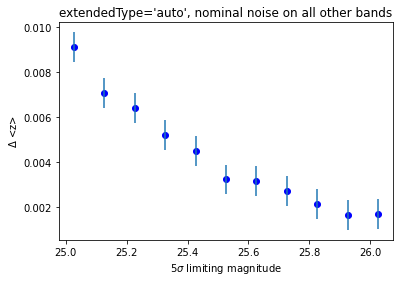

In [22]:
plt.plot(outputs['m5'],outputs['meanz']-outputs['true_meanz'],'bo')
plt.errorbar(outputs['m5'],outputs['meanz']-outputs['true_meanz'],outputs['meanz_err'],
            fmt='none')
plt.xlabel(r'5$\sigma$ limiting magnitude')
plt.ylabel(r'$\Delta$ <z>')
plt.title("extendedType='auto', nominal noise on all other bands")

Text(0.5, 1.0, "extendedType='point'")

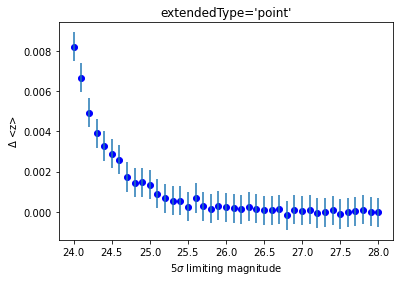

In [54]:
plt.plot(outputs['m5'],outputs['meanz']-outputs['true_meanz'],'bo')
plt.errorbar(outputs['m5'],outputs['meanz']-outputs['true_meanz'],outputs['meanz_err'],
            fmt='none')
plt.xlabel(r'5$\sigma$ limiting magnitude')
plt.ylabel(r'$\Delta$ <z>')
plt.title("extendedType='point'")

Text(0.5, 1.0, "extendedType='auto'")

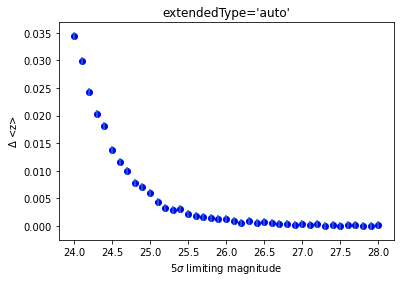

In [57]:
plt.plot(outputs['m5'],outputs['meanz']-outputs['true_meanz'],'bo')
plt.errorbar(outputs['m5'],outputs['meanz']-outputs['true_meanz'],outputs['meanz_err'],
            fmt='none')
plt.xlabel(r'5$\sigma$ limiting magnitude')
plt.ylabel(r'$\Delta$ <z>')
plt.title("extendedType='auto'")

In [58]:
tmpcatalog["u"].to_numpy()

array([26.074991, 26.069508, 27.736233, ..., 25.428364, 26.282116,
       24.405556], dtype=float32)

In [ ]:
# try computring m5

In [75]:
tmpcatalog[:5]

,ellipticity,size,redshift,u,g,r,i,i_err,z,y,major,minor
0,0.353410,0.175397,0.578392,26.074991,25.764059,25.007959,24.458531,0.016227,24.283455,24.131334,0.175397,0.083795
1,0.104118,0.089400,2.382155,26.069508,25.777227,25.783318,25.943175,0.041545,25.963848,25.999722,0.089400,0.072539
2,0.118226,0.549516,0.903188,27.736233,26.733599,25.332582,24.326574,0.039787,23.642782,23.414021,0.549516,0.433320
3,0.231982,0.186271,1.818212,26.239840,25.765402,25.611401,25.449278,0.036554,25.032290,24.794418,0.186271,0.116121
4,0.069263,0.125602,0.541089,28.264460,26.621662,25.306196,24.583402,0.016882,24.299145,24.122648,0.125602,0.109330
